<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [536]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np

In [537]:
#Importation de la librairie plotly express
import plotly.express as px
import matplotlib.pyplot as plt

In [538]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [539]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("files/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("files/erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("files/liaison.xlsx")

/Users/patty/Python/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/Users/patty/Python/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/Users/patty/Python/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [540]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [541]:
#Consulter le nombre de colonnes
df_erp.shape[1]
#La nature des données dans chacune des colonnes
df_erp.info()
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [542]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [543]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.loc[df_erp.product_id.duplicated()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [544]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp.stock_status.unique()
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
# stock_quantity

array(['instock', 'outofstock'], dtype=object)

In [545]:
#Création d'une colonne "stock_status_2"
df_erp['stock_status_2'] = ""

#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = np.where(
    df_erp['stock_quantity'] <= 0,
    'outofstock',
    'instock'
)

In [546]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [547]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(823)

In [548]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [549]:
#Corriger la ou les données incohérentes
df_erp = df_erp.rename(columns={'stock_status_2': 'stock_status_clean'})

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp.loc[(df_erp['stock_status_clean'] == 'outofstock') & (df_erp['stock_quantity'] > 0)]  # should be zero

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_clean


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [550]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum : {df_erp['price'].min()}")
#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum : {df_erp['price'].max()}")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp.loc[df_erp['price'] <= 0])
df_erp['negative_price_flag'] = df_erp.price < 0

Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0
Prix maximum : 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_clean
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [551]:
# price < purchase_price (marge < -0.5)

df_erp['marge'] = (df_erp.price - df_erp.purchase_price) / df_erp.purchase_price
df_erp['marge_error'] = df_erp.marge < -0.5

df_erp.loc[(df_erp.marge < -0.5) & (df_erp.price > 0), ['product_id', 'price', 'purchase_price', 'stock_quantity', 'marge']]

,product_id,price,purchase_price,stock_quantity,marge
210,4355,12.65,77.48,97,-0.836732


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [552]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Quantité minimum : {df_erp['stock_quantity'].min()}")
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Quantité maximum : {df_erp['stock_quantity'].max()}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp.loc[df_erp['stock_quantity'] < 0])

Quantité minimum : -10
Quantité maximum : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_clean,negative_price_flag,marge,marge_error
449,4973,0,10.0,-10,outofstock,4.96,outofstock,False,1.016129,False
573,5700,1,44.5,-1,outofstock,22.30,outofstock,False,0.995516,False


In [553]:
# flag les stocks inférieurs à 0 pour l'analysis
df_erp['negative_stock_flag'] = df_erp.stock_quantity < 0

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [554]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()

array([1, 0])

In [555]:
#Quelles sont les colonnes à conserver selon vous?
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

df_erp_analysis = df_erp.loc[(~df_erp.negative_price_flag) & (~df_erp.marge_error) & (~df_erp.negative_stock_flag)].drop(columns=['stock_status', 'negative_price_flag', 'marge', 'marge_error', 'negative_stock_flag'])

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [556]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp_analysis['purchase_price'].isna().sum()
#Afficher le prix minimum de la colonne "purchase_price"
print(f"purchase_price minimum : {df_erp_analysis['purchase_price'].min()}")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"purchase_price maximum : {df_erp_analysis['purchase_price'].max()}")

purchase_price minimum : 2.74
purchase_price maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [557]:
#Dimension du dataset
#Nombre d'observations
display(df_web.shape[0])
#Nombre de caractéristiques
display(df_web.shape[1])

1513

29

In [558]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
df_web.info()
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

sku                      1428
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales              1430
tax_status                716
tax_class                   0
post_author              1430
post_date                1430
post_date_gmt            1430
post_content                0
product_type             1429
post_title               1430
post_excerpt              716
post_status              1430
comment_status           1430
ping_status              1430
post_password               0
post_name                1430
post_modified            1430
post_modified_gmt        1430
post_content_filtered       0
post_parent              1430
guid                     1430
menu_order               1430
post_type                1430
post_mime_type            714
comment_count            1430
dtype: int64

In [559]:
#Selon vous, quelles sont les colonnes à conserver/supprimer ?
cols_web_keep = [
    'sku',
    'total_sales',
    'tax_status',
    'product_type',
    'post_type',
    'post_name'
]
for i in df_web.columns:
    nb = len(df_web[i].unique())
    if nb <= 2:
        print(f"{i} unique values : {nb}")
        print(df_web[i].unique())

virtual unique values : 1
[0]
downloadable unique values : 1
[0]
rating_count unique values : 1
[0]
average_rating unique values : 2
[ 0. nan]
tax_status unique values : 2
[nan 'taxable']
tax_class unique values : 1
[nan]
post_content unique values : 1
[nan]
post_status unique values : 2
['publish' nan]
comment_status unique values : 2
['closed' nan]
ping_status unique values : 2
['closed' nan]
post_password unique values : 1
[nan]
post_content_filtered unique values : 1
[nan]
post_parent unique values : 2
[ 0. nan]
menu_order unique values : 2
[ 0. nan]
post_mime_type unique values : 2
['image/jpeg' nan]
comment_count unique values : 2
[ 0. nan]


In [560]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web_analysis = df_web[cols_web_keep]

In [561]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web['sku'].isna().sum()

np.int64(85)

In [562]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
#Identifier les lignes sans code article
df_web_analysis.loc[df_web_analysis['sku'].isna()]

,sku,total_sales,tax_status,product_type,post_type,post_name
8,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN


In [563]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
df_web_analysis.loc[df_web_analysis['sku'].isna()].head()

,sku,total_sales,tax_status,product_type,post_type,post_name
8,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN


In [564]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web_analysis.loc[df_web_analysis.duplicated()]

,sku,total_sales,tax_status,product_type,post_type,post_name
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN


In [565]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_no_id = df_web_analysis.loc[df_web_analysis['sku'].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_no_id.info()
#3 - Que constatez-vous?
df_web_analysis = df_web_analysis.loc[df_web_analysis['sku'].notna()]

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   tax_status    2 non-null      object 
 3   product_type  2 non-null      object 
 4   post_type     2 non-null      object 
 5   post_name     2 non-null      object 
dtypes: float64(1), object(5)
memory usage: 4.6+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [566]:
#Dimension du dataset
#Nombre d'observations
display(df_liaison.shape[0])
#Nombre de caractéristiques
display(df_liaison.shape[1])

825

2

In [567]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
df_liaison.info()
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


id_web        734
product_id    825
dtype: int64

In [568]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques? -> oui
len(df_liaison.product_id.unique())

825

In [569]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques? -> oui, mais il y a des valeurs nulles
len(df_liaison.id_web.unique())

735

In [570]:
#Avons-nous des articles sans correspondance? -> oui
df_liaison.loc[df_liaison.id_web.isna()]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [571]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(
    left=df_erp_analysis,
    right=df_liaison,
    on='product_id',
    how='left'
)

In [572]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
product_id_list = df_erp_analysis.product_id
df_liaison.loc[~df_liaison.product_id.isin(product_id_list)]

,id_web,product_id
151,NaN,4233
210,12589,4355
449,NaN,4973
469,NaN,5017
573,14736,5700
739,NaN,6594


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [573]:
#Fusionner les datasets df_merge et df_web
df_web_only_product = df_web_analysis.loc[df_web_analysis.post_type == 'product']

df_merge = pd.merge(
    left=df_merge,
    right=df_web_only_product,
    left_on='id_web',
    right_on='sku',
    how='left'
)

In [574]:
#Avons-nous des lignes sans correspondance?
df_merge.loc[df_merge['sku'].isna()].head()

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_clean,id_web,sku,total_sales,tax_status,product_type,post_type,post_name
19,4055,0,86.1,0,37.88,outofstock,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,4090,0,73.0,0,33.79,outofstock,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,4092,0,47.0,0,25.25,outofstock,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,4195,0,14.1,0,7.36,outofstock,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,4209,0,73.5,0,33.01,outofstock,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

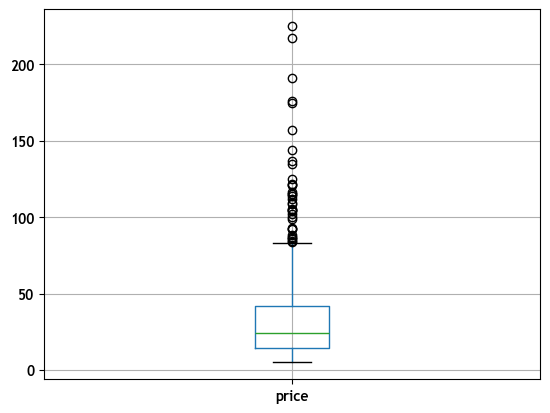

In [575]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge.boxplot(
    column='price'
)
plt.show()

In [576]:
#Autre méthode avec plotly express
# For points: outliers / suspectedoutliers / all / False
fig = px.box(
    df_merge,
    x='price',
    points='suspectedoutliers'
)
fig.update_layout(
    yaxis_title="",
    xaxis_title="Prix"
)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [577]:
#Calculer la moyenne du prix
moyenne_prix = df_merge['price'].mean()
#Calculer l'écart-type du prix
std_prix = df_merge.price.std()
#Calculer le Z-score
df_merge['price_zscore'] = (df_merge.price - moyenne_prix) / std_prix

In [578]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_merge.loc[df_merge.price_zscore > 3, 'price'].min()

np.float64(114.0)

In [579]:
# outliers (z-score > 3)
nb_prix_outlier = df_merge.loc[df_merge.price_zscore > 3].price.count()
prop_prix_outlier = round(nb_prix_outlier / df_merge.price.count() * 100, 2)

print(f"Nombre d'outliers : {nb_prix_outlier}")
print(f"Proportion d'outliers : {prop_prix_outlier} %")

Nombre d'outliers : 17
Proportion d'outliers : 2.08 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [580]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.price.describe()

count    819.000000
mean      32.386813
std       26.647466
min        5.200000
25%       14.650000
50%       24.400000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [581]:
#Définir un seuil pour les articles "outliers" en prix
Q1_PRIX = df_merge.price.quantile(0.25)
Q3_PRIX = df_merge.price.quantile(0.75)
IQR_PRIX = Q3_PRIX - Q1_PRIX

lower_bound_prix = Q1_PRIX - 1.5 * IQR_PRIX
higher_bound_prix = Q3_PRIX + 1.5 * IQR_PRIX

In [582]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_merge['price_outlier_iqr'] = (df_merge.price > higher_bound_prix) | (df_merge.price < lower_bound_prix)
nb_prix_outlier = df_merge.price_outlier_iqr.sum()
prop_prix_outlier = round(nb_prix_outlier / df_merge.price.count() * 100, 2)

print(f"Nombre d'outliers : {nb_prix_outlier}")
print(f"Proportion d'outliers : {prop_prix_outlier} %")

Nombre d'outliers : 36
Proportion d'outliers : 4.4 %


In [583]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
df_merge.loc[df_merge.price_outlier_iqr == True, ['product_id', 'price', 'purchase_price', 'product_type', 'post_name', 'price_zscore']].sort_values('price', ascending=False).head()

,product_id,price,purchase_price,product_type,post_name,price_zscore
207,4352,225.0,137.81,Champagne,champagne-egly-ouriet-grand-cru-millesime-2008,7.228199
457,5001,217.5,116.87,Vin,david-duband-charmes-chambertin-grand-cru-2014,6.946746
630,5892,191.3,116.06,Champagne,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,5.963538
225,4402,176.0,78.25,Cognac,cognac-frapin-vip-xo,5.389375
593,5767,175.0,90.42,Vin,camille-giroud-clos-de-vougeot-2016,5.351848


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [584]:
##############################
# Calculer le CA du site web #
##############################

# Only sales online
df_merge_site = df_merge.loc[df_merge.onsale_web == 1]

#Créer une colonne calculant le CA par article
df_merge_site['ca_par_article'] = df_merge_site.price * df_merge_site.total_sales

#Calculer la somme de la colonne "ca_par_article"
somme_ca = df_merge_site.ca_par_article.sum()

#Ce résultat correspond au chiffre d'affaire du site web
somme_ca

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_37253/3928808420.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



np.float64(143242.90000000002)

In [585]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge_site = df_merge_site.sort_values('ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge_site = df_merge_site.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
top20_ca = df_merge_site[['product_id', 'product_type', 'ca_par_article']].reset_index().head(20)
top20_ca.product_id = top20_ca.product_id.astype(str)  # if not, the graph will not show

#Graphique en barre des 20 premiers articles avec plotly express
top20_ca = top20_ca.sort_values('ca_par_article')  # to make the highest value on top
top20_ca['label'] = (
    top20_ca.product_id.astype(str)
    + " ("
    + top20_ca.product_type
    + ")"
)

fig = px.bar(
    top20_ca,
    x='ca_par_article',
    y='label',
    orientation='h',
    text='ca_par_article',
    title="Top 20 des articles par chiffre d’affaires",
    labels={
        'ca_par_article': 'Chiffre d’affaires (€)',
        'label': 'Produit'
    },
    height=800
)
fig.update_traces(
    texttemplate='%{text:.0f} €',
    textposition='outside',        # can also be 'inside'
    marker_color='steelblue'
)
fig.show()

In [586]:
# graphique vertical
top20_ca = top20_ca.sort_values('ca_par_article', ascending=False)

fig = px.bar(
    top20_ca,
    x='product_id',
    y='ca_par_article',
    text='ca_par_article',
    title="Top 20 des articles par chiffre d’affaires",
    labels={
        'ca_par_article': 'Chiffre d’affaires (€)',
        'product_id': 'Produit'
    }
)
fig.update_traces(
    texttemplate='%{text:.0f} €',
    textposition='outside',        # can also be 'inside'
    marker_color='steelblue'
)
fig.show()

In [587]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge_site['part_ca'] = df_merge_site.ca_par_article / somme_ca

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_site['cumsum_ca'] = df_merge_site.part_ca.cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_product_80 = len(df_merge_site.loc[df_merge_site.cumsum_ca <= 0.81])

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
total_product_online = df_merge_site.product_id.count()
print(f"Nombre d'articles représentant 80% CA : {nb_product_80} (total : {total_product_online})")
print(f"Proportion d'articles représentant 80% CA : {round(nb_product_80 / total_product_online * 100, 3)} %")

Nombre d'articles représentant 80% CA : 443 (total : 714)
Proportion d'articles représentant 80% CA : 62.045 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [588]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge_site = df_merge_site.sort_values('total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge_site = df_merge_site.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
top20_sales = df_merge_site[['product_id', 'product_type', 'total_sales']].head(20)
top20_sales.product_id = top20_sales.product_id.astype(str)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    top20_sales,
    x='product_id',
    y='total_sales',
    text='total_sales',
    title="Top 20 articles en quantité",
    labels={
        'product_id': 'Produit',
        'total_sales': 'Quantité vendue'
    }
)
fig.update_traces(
    textposition='inside',
    marker_color='teal'
)
fig.show()

In [589]:
###################################
# Calculer le 20 / 80 en quantité #
###################################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_sales = df_merge_site.total_sales.sum()
df_merge_site['part_quantite'] = df_merge_site.total_sales / total_sales

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_site['cumsum_quantite'] = df_merge_site.part_quantite.cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_sales_80 = len(df_merge_site.loc[df_merge_site.cumsum_quantite <= 0.81])

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"Nombre d'articles représentant 80% de ventes en quantité : {nb_sales_80} (total : {total_product_online})")
print(f"Proportion d'articles représentant 80% de ventes en quantité : {round(nb_sales_80 / total_product_online * 100, 3)} %")

Nombre d'articles représentant 80% de ventes en quantité : 439 (total : 714)
Proportion d'articles représentant 80% de ventes en quantité : 61.485 %


In [590]:
# Comparer les produits entre les 2 calculs 20/80
top20_ca_product = top20_ca.product_id
top20_sales_product = top20_sales.product_id

top20_ca_product.loc[top20_ca_product.isin(top20_sales_product)]

3     5826
12    4647
Name: product_id, dtype: object

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [591]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Création de la colonne Rotation de stock
df_merge_site['rotation_stock_mois'] = df_merge_site.stock_quantity / df_merge_site.total_sales

#Remplacement des "inf" par 0
df_merge_site.rotation_stock_mois = df_merge_site.rotation_stock_mois.replace(
    np.inf,
    0
).fillna(0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge_site.sort_values('rotation_stock_mois', ascending=False, inplace=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
top20_flop_stock = df_merge_site[['product_id', 'product_type', 'rotation_stock_mois']].head(20)
top20_flop_stock['label_name'] = (
    top20_flop_stock.product_id.astype(str)
    + " ("
    + top20_flop_stock.product_type
    + ")"
)

top20_flop_stock.product_id = top20_flop_stock.product_id.astype(str)
fig = px.bar(
    top20_flop_stock,
    x='product_id',
    y='rotation_stock_mois',
    text='rotation_stock_mois',
    labels={
        'product_id': 'Produit',
        'rotation_stock_mois': 'Nombre de mois de stock'
    },
    title='Top 20 Flop Produits'
)
fig.update_traces(
    marker_color='seagreen',
    texttemplate='%{text:.0f}'
)
fig.show()

In [592]:
# horizontal graph
top10_flop_stock = top20_flop_stock.sort_values('rotation_stock_mois', ascending=False).head(10)
fig = px.bar(
    top10_flop_stock.sort_values('rotation_stock_mois'),
    x='rotation_stock_mois',
    y='label_name',
    orientation="h",
    text='rotation_stock_mois',
    labels={
        'label_name': 'Produit',
        'rotation_stock_mois': 'Nombre de mois de stock'
    },
    title='Top 10 nombre de mois de stock',
    height=500
)
fig.update_traces(
    marker_color='seagreen',
    texttemplate='%{text:.0f}'
)
fig.show()

In [593]:
# boxplot
fig = px.box(
    df_merge_site,
    x='rotation_stock_mois',
    hover_data=['rotation_stock_mois'],
    hover_name='product_type',  # tiny label title
    title="Distribution de nombre de mois de stock"
)
fig.update_traces(
    marker_color='indianred'
)
fig.show()

In [594]:
# Nombre de mois de stock par type de produits
nb_mois_stock_par_type = df_merge_site.groupby('product_type').agg({'rotation_stock_mois': 'mean'}).reset_index()
nb_mois_stock_par_type.rotation_stock_mois = nb_mois_stock_par_type.rotation_stock_mois.round(2)

In [595]:
# graphique
fig = px.bar(
    nb_mois_stock_par_type.sort_values('rotation_stock_mois'),
    x='product_type',
    y='rotation_stock_mois',
    text='rotation_stock_mois',
    labels={
        'product_type': 'Produit',
        'rotation_stock_mois': 'Nombre de mois de stock'
    },
    title='Nombre de mois de stock par type',
    height=500
)
fig.update_traces(
    marker_color='seagreen',
    texttemplate='%{text:.1f}',
    textposition='outside'
)
fig.show()

In [596]:
# Nombre de mois de stock globalement
nb_mois_stock_global = nb_mois_stock_par_type.rotation_stock_mois.mean().round(2)
print(f"Nombre de mois de stock globalement : {nb_mois_stock_global}")

Nombre de mois de stock globalement : 5.02


In [597]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['valorisation_stock_euros'] = df_merge.stock_quantity * df_merge.purchase_price

#Calculer la somme de la colonne "Valorisation_stock_euros"
somme_valorisation_stock = df_merge['valorisation_stock_euros'].sum()

In [598]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
somme_stock = df_merge.stock_quantity.sum()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [599]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT (TVA = 20%)
df_merge['price_ht'] = df_merge.price
df_merge.loc[df_merge.tax_status == 'taxable', 'price_ht'] /= 1.2

#Création de la colonne Taux de marge
df_merge['taux_marge'] = (df_merge.price_ht - df_merge.purchase_price) / df_merge.purchase_price

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Minimum taux_marge : {df_merge.taux_marge.min().round(2)}")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Maximum taux_marge : {df_merge.taux_marge.max().round(2)}")


Minimum taux_marge : -0.17
Maximum taux_marge : 1.27


In [600]:
#Affichage de la ligne avec un taux de marge inférieur à 0
display(df_merge.loc[df_merge.taux_marge < 0])

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_clean,id_web,sku,total_sales,tax_status,product_type,post_type,post_name,price_zscore,price_outlier_iqr,valorisation_stock_euros,price_ht,taux_marge
389,4864,0,8.3,0,9.99,outofstock,15154,NaN,NaN,NaN,NaN,NaN,NaN,-0.903906,False,0.0,8.3,-0.169169
719,6324,0,92.0,18,99.00,instock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.237105,True,1782.0,92.0,-0.070707
811,7196,0,31.0,55,31.20,instock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.052043,False,1716.0,31.0,-0.006410


In [601]:
#Création d'un dataframe avec les taux positifs
df_merge_taux_positif = df_merge.loc[df_merge.taux_marge > 0]

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Minimum taux_marge : {df_merge_taux_positif.taux_marge.min().round(2)}")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Maximum taux_marge : {df_merge_taux_positif.taux_marge.max().round(2)}")

Minimum taux_marge : 0.29
Maximum taux_marge : 1.27


In [602]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_merge_product_type = df_merge_taux_positif.copy()
df_merge_product_type.product_type = df_merge_product_type.product_type.fillna('Type inconnu')
df_merge_product_type = df_merge_product_type.groupby('product_type')['taux_marge'].mean().reset_index()
df_merge_product_type.taux_marge = (df_merge_product_type.taux_marge * 100).round(2)

#Affichage dans un graphique du taux de marge par type de produit
fig = px.box(
    df_merge_product_type,
    x='taux_marge',
    points='all',
    hover_data=['taux_marge'],
    hover_name='product_type',  # tiny label title
    title="Distribution du taux de marge par type de produit"
)
fig.update_traces(
    marker_color='indianred'
)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

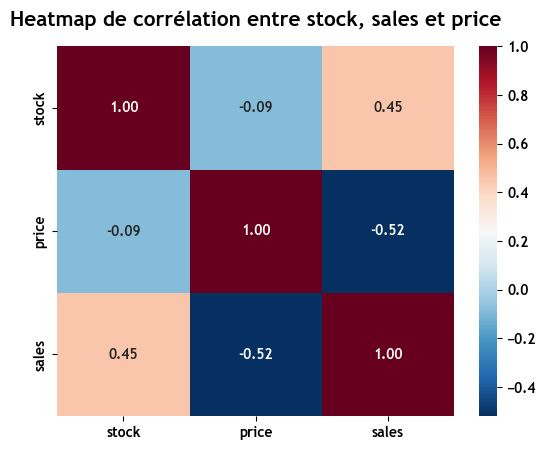

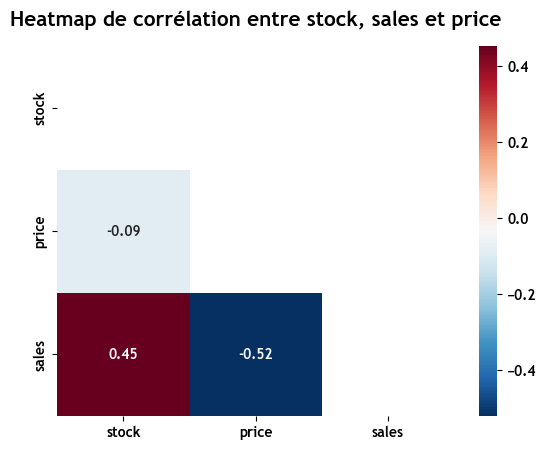

In [603]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns

# Config UI
plt.rcParams.update({
    "font.family": "Trebuchet MS",
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Make title with plt
def makeTitle(title):
    plt.title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

#Création d'une heatmap de corrélation avec les variables stock, sales et price
corr = df_merge[['stock_quantity', 'price', 'total_sales']].corr()

sns.heatmap(
    corr,
    fmt='.2f',
    annot=True,
    xticklabels=['stock', 'price', 'sales'],
    yticklabels=['stock', 'price', 'sales'],
    cmap='RdBu_r'
)
makeTitle("Heatmap de corrélation entre stock, sales et price")
plt.show()

#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(corr))  # triu (triangle upper); In Seaborn, mask: 1 (True) -> hide, 0 (False) -> show
sns.heatmap(
    corr,
    fmt='.2f',
    annot=True,
    mask=mask,
    xticklabels=['stock', 'price', 'sales'],
    yticklabels=['stock', 'price', 'sales'],
    cmap='RdBu_r'
)
makeTitle("Heatmap de corrélation entre stock, sales et price")
plt.show()

In [604]:
#Que peut-on conclure des corrélations ?
# stock ⬆ et sales ⬆, la corrélation modérée de 0,44.
# stock vs. price, pas significativement lié (corrélation faible de -0,09).
# price ⬇ et sales ⬆, la corrélation négative modérée de -0,52.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  

# Fichier principal
# df_merge.to_excel('df_merge.xlsx', index=False)

# Fichier pour les calculs sur les produits du site Web
# df_merge_site.to_excel('df_merge_site.xlsx', index=False)